# ESA GeoFM — Attention Fusion (AlphaEarth + TerraMind S2)

**What's new vs dual_branch:**
- Cross-attention upsampling: each 256×256 pixel attends over TerraMind 16×16 patch tokens
- Gradient loss on height (sharper building/tree edges)
- Robust checkpoint system: best model + last epoch + history saved every epoch
- Auto-resume from any checkpoint after runtime crash

**Scoring:** mIoU_build×0.25 + mIoU_trees×0.15 + mIoU_water×0.15 + RMSE_H_build×0.25 + RMSE_H_veg×0.20

## 0 — Mount & install

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
!pip install -q rasterio

Mounted at /content/drive


## 1 — Imports & config

In [ ]:
import re, random, warnings, shutil, zipfile, json
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import rasterio
warnings.filterwarnings('ignore', category=rasterio.errors.NotGeoreferencedWarning)

# ── Paths ─────────────────────────────────────────────────────────────────────
DRIVE_ROOT  = Path('/content/drive/MyDrive/ESA_Challenge')
AE_TRAIN    = DRIVE_ROOT / 'train' / 'alphaearth_emb'
TM_TRAIN    = DRIVE_ROOT / 'train' / 'terramind_s2_emb'
LABEL_DIR   = DRIVE_ROOT / 'train' / 'labels'
AE_TEST     = DRIVE_ROOT / 'test'  / 'alphaearth_emb'
TM_TEST     = DRIVE_ROOT / 'test'  / 'terramind_test_s2_emb'
NORM_STATS  = DRIVE_ROOT / 'norm_stats.npy'

# Checkpoint paths — all on Drive so they survive runtime crashes
CKPT_BEST   = DRIVE_ROOT / 'attn_best.pth'       # best val_loss ever
CKPT_LAST   = DRIVE_ROOT / 'attn_last.pth'       # most recent epoch
HISTORY_F   = DRIVE_ROOT / 'attn_history.json'   # full training log

# ── Hyperparams ───────────────────────────────────────────────────────────────
BATCH_SIZE  = 8
EPOCHS      = 60
LR          = 3e-4
VAL_FRAC    = 0.15
SEED        = 42
SAVE_EVERY  = 1    # save checkpoint every N epochs
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

# ── Keep-alive ────────────────────────────────────────────────────────────────
from IPython.display import display, Javascript
display(Javascript("""
setInterval(() => {
  document.querySelectorAll('colab-toolbar-button#connect').forEach(b => b.click());
}, 60000);
console.log('Keep-alive active');
"""))

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


<IPython.core.display.Javascript object>

## 2 — Copy train data to local SSD

In [ ]:
from google.colab import drive as _drive

LOCAL_AE  = Path('/content/train_ae')
LOCAL_TM  = Path('/content/train_tm')
LOCAL_LBL = Path('/content/train_labels')
for p in [LOCAL_AE, LOCAL_TM, LOCAL_LBL]:
    p.mkdir(exist_ok=True)

def safe_copy(src, dst):
    try:
        shutil.copy2(src, dst)
    except OSError:
        _drive.mount('/content/drive', force_remount=True)
        shutil.copy2(src, dst)

for src_dir, dst_dir, label in [
    (AE_TRAIN,  LOCAL_AE,  'AlphaEarth'),
    (TM_TRAIN,  LOCAL_TM,  'TerraMind S2'),
    (LABEL_DIR, LOCAL_LBL, 'Labels'),
]:
    files = sorted(src_dir.glob('*.tif'))
    missing = [f for f in files if not (dst_dir / f.name).exists()]
    if missing:
        print(f'Copying {len(missing)} {label} files → SSD…')
        for p in missing:
            safe_copy(p, dst_dir / p.name)
    else:
        print(f'{label}: already on SSD ({len(files)} files)')

print(f'Done. AE={len(list(LOCAL_AE.glob("*.tif")))}  '
      f'TM={len(list(LOCAL_TM.glob("*.tif")))}  '
      f'Labels={len(list(LOCAL_LBL.glob("*.tif")))}')

Copying 2024 AlphaEarth files → SSD…
Mounted at /content/drive
Copying 2024 TerraMind S2 files → SSD…
Copying 2024 Labels files → SSD…
Done. AE=2024  TM=2024  Labels=2024


## 2b — Pre-normalise AlphaEarth → float16 .npy (run once)

In [ ]:
LOCAL_AE_NPY = Path('/content/train_ae_npy')
LOCAL_AE_NPY.mkdir(exist_ok=True)

stats_tmp = np.load(NORM_STATS, allow_pickle=True).item()
_ae_mean  = stats_tmp['alphaearth_emb']['mean'].reshape(-1,1,1).astype(np.float32)
_ae_std   = stats_tmp['alphaearth_emb']['std'].reshape(-1,1,1).astype(np.float32)

tif_files   = sorted(LOCAL_AE.glob('*.tif'))
npy_missing = [f for f in tif_files
               if not (LOCAL_AE_NPY / (f.stem + '.npy')).exists()]
print(f'Pre-normalising {len(npy_missing)} AlphaEarth files → float16 .npy…')

for p in npy_missing:
    with rasterio.open(p) as src:
        arr = src.read().astype(np.float32)
    if arr.shape[-1] != 256 or arr.shape[-2] != 256:
        t   = torch.from_numpy(arr).unsqueeze(0)
        arr = F.interpolate(t, size=(256,256), mode='bilinear',
                            align_corners=False).squeeze(0).numpy()
    arr = (arr - _ae_mean) / (_ae_std + 1e-6)
    arr = np.nan_to_num(arr, nan=0.0).astype(np.float16)
    np.save(LOCAL_AE_NPY / (p.stem + '.npy'), arr)

print(f'Done. {len(list(LOCAL_AE_NPY.glob("*.npy")))} .npy files ready.')

Pre-normalising 2024 AlphaEarth files → float16 .npy…
Done. 2024 .npy files ready.


## 3 — Norm stats

In [ ]:
stats   = np.load(NORM_STATS, allow_pickle=True).item()
AE_MEAN = stats['alphaearth_emb']['mean'].reshape(-1,1,1).astype(np.float32)
AE_STD  = stats['alphaearth_emb']['std'].reshape(-1,1,1).astype(np.float32)
TM_MEAN = stats['terramind_s2_emb']['mean'].reshape(-1,1,1).astype(np.float32)
TM_STD  = stats['terramind_s2_emb']['std'].reshape(-1,1,1).astype(np.float32)
print(f'AE norm: {AE_MEAN.shape[0]}ch   TM norm: {TM_MEAN.shape[0]}ch')

AE norm: 64ch   TM norm: 768ch


## 4 — Dataset

In [ ]:
def patch_id(stem):
    m = re.search(r'_(\d{4})_', stem)
    return m.group(1) if m else None

def load_tif(path, target_hw=None):
    with rasterio.open(path) as src:
        arr = src.read().astype(np.float32)
    if target_hw and (arr.shape[-1] != target_hw or arr.shape[-2] != target_hw):
        arr = F.interpolate(torch.from_numpy(arr).unsqueeze(0),
                            size=(target_hw, target_hw),
                            mode='bilinear', align_corners=False
                           ).squeeze(0).numpy()
    return arr


class DualBranchDataset(Dataset):
    def __init__(self, ae_files, tm_files, lbl_files, augment=False):
        self.ae_files  = ae_files
        self.tm_files  = tm_files
        self.lbl_files = lbl_files
        self.augment   = augment

    def __len__(self):
        return len(self.ae_files)

    def __getitem__(self, idx):
        try:
            ae  = np.load(self.ae_files[idx]).astype(np.float32)
            tm  = load_tif(self.tm_files[idx])
            lbl = load_tif(self.lbl_files[idx], target_hw=256)
        except Exception:
            ae  = np.zeros((64,  256, 256), dtype=np.float32)
            tm  = np.zeros((768,  16,  16), dtype=np.float32)
            lbl = np.zeros((4,   256, 256), dtype=np.float32)

        tm     = np.nan_to_num((tm - TM_MEAN) / (TM_STD + 1e-6), nan=0.0)
        seg    = lbl[:3].clip(0, 1)
        height = np.log1p(lbl[3:4].clip(0, None))

        ae, tm, seg, height = (torch.from_numpy(x)
                                for x in (ae, tm, seg, height))

        if self.augment:
            if random.random() > 0.5:
                ae, tm, seg, height = [torch.flip(t, [-1])
                                       for t in (ae, tm, seg, height)]
            if random.random() > 0.5:
                ae, tm, seg, height = [torch.flip(t, [-2])
                                       for t in (ae, tm, seg, height)]
            k = random.randint(0, 3)
            if k:
                ae, tm, seg, height = [torch.rot90(t, k, [-2,-1])
                                       for t in (ae, tm, seg, height)]
        return ae, tm, seg, height


# Build file lists
ae_map  = {patch_id(p.stem): p for p in LOCAL_AE_NPY.glob('*.npy') if patch_id(p.stem)}
tm_map  = {patch_id(p.stem): p for p in LOCAL_TM.glob('*.tif')     if patch_id(p.stem)}
lbl_map = {patch_id(p.stem): p for p in LOCAL_LBL.glob('*.tif')    if patch_id(p.stem)}
ids     = sorted(ae_map.keys() & tm_map.keys() & lbl_map.keys())
random.shuffle(ids)
n_val   = int(len(ids) * VAL_FRAC)
val_ids, trn_ids = ids[:n_val], ids[n_val:]

def make_lists(ids):
    return ([ae_map[i]  for i in ids],
            [tm_map[i]  for i in ids],
            [lbl_map[i] for i in ids])

trn_ds = DualBranchDataset(*make_lists(trn_ids), augment=True)
val_ds = DualBranchDataset(*make_lists(val_ids),  augment=False)
trn_loader = DataLoader(trn_ds, batch_size=BATCH_SIZE, shuffle=True,
                        num_workers=2, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True, persistent_workers=True)

print(f'Matched patches: {len(ids)}   Train: {len(trn_ids)}   Val: {len(val_ids)}')
ae, tm, seg, ht = trn_ds[0]
print(f'AE:{ae.shape}  TM:{tm.shape}  seg:{seg.shape}  ht:{ht.shape}')

Matched patches: 2024   Train: 1721   Val: 303
AE:torch.Size([64, 256, 256])  TM:torch.Size([768, 16, 16])  seg:torch.Size([3, 256, 256])  ht:torch.Size([1, 256, 256])


## 5 — Model: Attention Fusion

**Key change vs dual_branch:** instead of bilinear upsampling TerraMind 16×16 → 256×256,
we use cross-attention: each of the 256×256 spatial positions queries all 256 TerraMind
patch tokens. The model learns *which* patch tokens matter for each output pixel.
This is architecturally motivated by ViT cross-attention (ADL Module 02).

In [ ]:
class ConvBnRelu(nn.Module):
    def __init__(self, ic, oc, k=3, p=1):
        super().__init__()
        self.b = nn.Sequential(
            nn.Conv2d(ic, oc, k, padding=p, bias=False),
            nn.BatchNorm2d(oc), nn.ReLU(inplace=True))
    def forward(self, x): return self.b(x)


class AttentionUpsample(nn.Module):
    """
    Cross-attention: spatial queries (from AlphaEarth 256x256)
    attend over TerraMind patch tokens (16x16 = 256 tokens).

    Each output pixel learns a weighted average of TerraMind tokens.
    This replaces bilinear upsampling with a learned, content-aware upsample.
    """
    def __init__(self, q_ch=64, kv_ch=768, out_ch=64, n_heads=4):
        super().__init__()
        self.out_ch  = out_ch
        self.q_proj  = nn.Conv2d(q_ch,  out_ch, 1)   # spatial queries
        self.kv_proj = nn.Linear(kv_ch, out_ch)       # patch-token keys/values
        self.attn    = nn.MultiheadAttention(out_ch, n_heads,
                                             batch_first=True, dropout=0.0)
        self.norm    = nn.LayerNorm(out_ch)
        self.out_proj = nn.Conv2d(out_ch, out_ch, 1)

    def forward(self, ae_feat, tm_tokens):
        """
        ae_feat  : (B, q_ch,  256, 256)
        tm_tokens: (B, kv_ch,  16,  16)
        returns  : (B, out_ch, 256, 256)
        """
        B, _, H, W = ae_feat.shape

        # Queries: one per spatial position
        Q = self.q_proj(ae_feat)              # (B, out_ch, H, W)
        Q = Q.flatten(2).permute(0, 2, 1)     # (B, H*W, out_ch)

        # Keys / Values: one per TerraMind patch token
        KV = tm_tokens.flatten(2).permute(0, 2, 1)   # (B, 256, kv_ch)
        KV = self.kv_proj(KV)                          # (B, 256, out_ch)

        # Cross-attention
        out, _ = self.attn(Q, KV, KV)         # (B, H*W, out_ch)
        out    = self.norm(out)
        out    = out.permute(0, 2, 1).view(B, self.out_ch, H, W)  # (B, C, H, W)
        return self.out_proj(out)


class AttentionFusionModel(nn.Module):
    """
    AlphaEarth (64, 256x256)  --[ae_encoder]--> (64, 256x256) --+
                                                                   |--> cat(128) --> decoder --> heads
    TerraMind  (768, 16x16)   --[AttentionUpsample]-----------> (64, 256x256) --+
    """
    def __init__(self):
        super().__init__()

        # AlphaEarth branch: refine pixel-level features
        self.ae_encoder = nn.Sequential(
            ConvBnRelu(64, 64),
            ConvBnRelu(64, 64),
        )

        # TerraMind branch: cross-attention upsample
        self.attn_up = AttentionUpsample(q_ch=64, kv_ch=768, out_ch=64, n_heads=4)

        # Decoder: fuse both branches
        self.decoder = nn.Sequential(
            ConvBnRelu(128, 128),
            ConvBnRelu(128,  64),
            ConvBnRelu( 64,  64),
        )

        self.seg_head    = nn.Conv2d(64, 3, 1)   # raw logits
        self.height_head = nn.Conv2d(64, 1, 1)

    def forward(self, ae, tm):
        a   = self.ae_encoder(ae)              # (B, 64, 256, 256)
        b   = self.attn_up(ae, tm)             # (B, 64, 256, 256) — attention fused
        x   = self.decoder(torch.cat([a, b], dim=1))
        return self.seg_head(x), F.softplus(self.height_head(x))


model    = AttentionFusionModel().to(DEVICE)
model    = torch.compile(model)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parameters: {n_params:,}')

with torch.no_grad():
    _ae = torch.randn(2, 64,  256, 256).to(DEVICE)
    _tm = torch.randn(2, 768,  16,  16).to(DEVICE)
    _s, _h = model(_ae, _tm)
print(f'Output — seg:{_s.shape}  height:{_h.shape}')
if DEVICE.type == 'cuda':
    print(f'VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB')

Parameters: 407,108


W0604 20:46:36.834000 5528 torch/_inductor/utils.py:1731] [0/0] Not enough SMs to use max_autotune_gemm mode


Output — seg:torch.Size([2, 3, 256, 256])  height:torch.Size([2, 1, 256, 256])
VRAM: 0.05 GB


## 6 — Loss & metrics

In [ ]:
def seg_loss(logits, target):
    """Weighted BCE: building×8, veg×1, water×3 (matches scoring weights)"""
    w   = torch.tensor([8.0, 1.0, 3.0], device=logits.device).view(1,3,1,1)
    bce = F.binary_cross_entropy_with_logits(logits, target, reduction='none')
    return (bce * w).mean()

def dice_loss(logits, target, ch=0, eps=1e-6):
    """Dice on a single channel — great for sparse classes like buildings."""
    p = torch.sigmoid(logits[:, ch])
    t = target[:, ch]
    return 1 - (2*(p*t).sum() + eps) / (p.sum() + t.sum() + eps)

def gradient_loss(pred, target):
    """
    Penalise blurry height boundaries by comparing image gradients.
    Inspired by perceptual/feature loss from ADL image restoration (Module 04).
    """
    def grad(x):
        dx = x[:,:,:,1:] - x[:,:,:,:-1]
        dy = x[:,:,1:,:] - x[:,:,:-1,:]
        return dx, dy
    pdx, pdy = grad(pred)
    tdx, tdy = grad(target)
    return F.l1_loss(pdx, tdx) + F.l1_loss(pdy, tdy)

def height_loss(pred, target):
    w    = 1.0 + (target > 0).float() * 2.0
    huber = (w * F.huber_loss(pred, target, delta=1.0, reduction='none')).mean()
    grad  = gradient_loss(pred, target)
    return huber + 0.1 * grad

def total_loss(logits, height, seg_t, height_t):
    return (seg_loss(logits, seg_t)
            + 2.0 * dice_loss(logits, seg_t, ch=0)   # buildings
            + 0.5 * dice_loss(logits, seg_t, ch=2)   # water
            + 1.5 * height_loss(height, height_t))

@torch.no_grad()
def compute_miou(logits, target, thresh=0.5):
    p   = (torch.sigmoid(logits) > thresh).float()
    t   = (target > thresh).float()
    inter = (p*t).sum(dim=(0,2,3))
    union = (p+t-p*t).sum(dim=(0,2,3))
    iou   = inter / (union + 1e-6)
    return iou.mean().item(), iou[0].item(), iou[1].item(), iou[2].item()

@torch.no_grad()
def compute_rmse(pred, target):
    return torch.sqrt(F.mse_loss(
        torch.expm1(pred).clamp(0),
        torch.expm1(target).clamp(0))).item()

print('Loss & metrics ready.')

Loss & metrics ready.


## 7 — Training loop

**Checkpoint strategy:**
- `attn_best.pth` — saved whenever val_loss improves (for inference)
- `attn_last.pth` — saved every epoch (for crash recovery)
- `attn_history.json` — full training log, survives runtime reset

**Auto-resume:** if `attn_last.pth` exists on Drive, training continues from that epoch automatically.

In [ ]:
def save_checkpoint(path, epoch, model, optimizer, scaler, scheduler,
                    val_loss, is_best=False):
    """Save full training state to Drive."""
    try:
        state = {
            'epoch':      epoch,
            'model':      model.state_dict(),
            'optimizer':  optimizer.state_dict(),
            'scaler':     scaler.state_dict(),
            'scheduler':  scheduler.state_dict(),
            'val_loss':   val_loss,
        }
        torch.save(state, path)
        if is_best:
            # Also save a clean inference-only checkpoint
            torch.save({'epoch': epoch, 'model': model.state_dict(),
                        'val_loss': val_loss}, CKPT_BEST)
    except Exception as e:
        print(f'  WARNING: checkpoint save failed: {e}')


def load_history():
    if HISTORY_F.exists():
        return json.loads(HISTORY_F.read_text())
    return []

def save_history(history):
    try:
        HISTORY_F.write_text(json.dumps(history, indent=2))
    except Exception as e:
        print(f'  WARNING: history save failed: {e}')


# ── Optimiser, scheduler, scaler ─────────────────────────────────────────────
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=EPOCHS, eta_min=LR/20)
scaler    = torch.amp.GradScaler('cuda')

# ── Auto-resume ───────────────────────────────────────────────────────────────
start_epoch    = 1
best_val_loss  = float('inf')
history        = load_history()

if CKPT_LAST.exists():
    print(f'Found checkpoint at {CKPT_LAST} — resuming…')
    ckpt = torch.load(CKPT_LAST, map_location=DEVICE, weights_only=False)
    try:
        model.load_state_dict(ckpt['model'])
    except RuntimeError:
        model._orig_mod.load_state_dict(ckpt['model'])
    optimizer.load_state_dict(ckpt['optimizer'])
    scaler.load_state_dict(ckpt['scaler'])
    scheduler.load_state_dict(ckpt['scheduler'])
    start_epoch   = ckpt['epoch'] + 1
    best_val_loss = ckpt['val_loss'] if CKPT_BEST.exists() else float('inf')
    if CKPT_BEST.exists():
        best_val_loss = torch.load(CKPT_BEST,
                                   map_location='cpu',
                                   weights_only=False)['val_loss']
    print(f'Resumed from epoch {ckpt["epoch"]}  best_val={best_val_loss:.4f}')
else:
    print('Starting fresh training.')

if start_epoch > EPOCHS:
    print(f'Already trained {EPOCHS} epochs. Nothing to do.')
else:
    print(f'Training epochs {start_epoch} → {EPOCHS}')
    print(f'Train batches: {len(trn_loader)}   Val batches: {len(val_loader)}')

# ── Training loop ─────────────────────────────────────────────────────────────
for epoch in range(start_epoch, EPOCHS + 1):

    # Train
    model.train()
    trn_loss = 0.0
    for ae, tm, seg_t, h_t in trn_loader:
        ae, tm     = ae.to(DEVICE), tm.to(DEVICE)
        seg_t, h_t = seg_t.to(DEVICE), h_t.to(DEVICE)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            seg_p, h_p = model(ae, tm)
            loss = total_loss(seg_p, h_p, seg_t, h_t)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        trn_loss += loss.item()
    trn_loss /= len(trn_loader)

    # Validate
    model.eval()
    val_loss = 0.0
    all_sp, all_st, all_hp, all_ht = [], [], [], []
    with torch.no_grad():
        for ae, tm, seg_t, h_t in val_loader:
            ae, tm     = ae.to(DEVICE), tm.to(DEVICE)
            seg_t, h_t = seg_t.to(DEVICE), h_t.to(DEVICE)
            with torch.amp.autocast('cuda'):
                seg_p, h_p = model(ae, tm)
                val_loss  += total_loss(seg_p, h_p, seg_t, h_t).item()
            all_sp.append(seg_p.float().cpu())
            all_st.append(seg_t.float().cpu())
            all_hp.append(h_p.float().cpu())
            all_ht.append(h_t.float().cpu())
    val_loss /= len(val_loader)

    miou, iou_b, iou_v, iou_w = compute_miou(
        torch.cat(all_sp), torch.cat(all_st))
    rmse_h = compute_rmse(torch.cat(all_hp), torch.cat(all_ht))
    scheduler.step()

    is_best = val_loss < best_val_loss
    if is_best:
        best_val_loss = val_loss

    # Save every epoch
    if epoch % SAVE_EVERY == 0 or is_best:
        save_checkpoint(CKPT_LAST, epoch, model, optimizer, scaler, scheduler,
                        val_loss, is_best=is_best)

    # Append to history and persist
    row = dict(epoch=epoch, trn=round(trn_loss,4), val=round(val_loss,4),
               miou=round(miou,4), iou_b=round(iou_b,4),
               iou_v=round(iou_v,4), iou_w=round(iou_w,4),
               rmse_h=round(rmse_h,3))
    history.append(row)
    save_history(history)

    tag = ' ✓ BEST' if is_best else ''
    if epoch % 5 == 0 or epoch == start_epoch or is_best:
        print(f'Ep {epoch:03d} | trn={trn_loss:.4f} val={val_loss:.4f} | '
              f'mIoU={miou:.3f} (b={iou_b:.3f} v={iou_v:.3f} w={iou_w:.3f}) '
              f'RMSE_H={rmse_h:.2f}m{tag}')

print(f'\nDone. Best val_loss={best_val_loss:.4f}')

Starting fresh training.
Training epochs 1 → 60
Train batches: 216   Val batches: 38
Ep 001 | trn=4.2441 val=3.2350 | mIoU=0.487 (b=0.199 v=0.757 w=0.504) RMSE_H=2.89m ✓ BEST
Ep 002 | trn=3.0376 val=2.6820 | mIoU=0.508 (b=0.218 v=0.792 w=0.514) RMSE_H=2.90m ✓ BEST
Ep 003 | trn=2.5591 val=2.4012 | mIoU=0.515 (b=0.244 v=0.792 w=0.508) RMSE_H=3.17m ✓ BEST
Ep 004 | trn=2.3321 val=2.2507 | mIoU=0.529 (b=0.244 v=0.806 w=0.536) RMSE_H=2.80m ✓ BEST
Ep 005 | trn=2.2295 val=2.2435 | mIoU=0.530 (b=0.252 v=0.805 w=0.533) RMSE_H=2.72m ✓ BEST
Ep 006 | trn=2.1840 val=2.1834 | mIoU=0.530 (b=0.262 v=0.793 w=0.535) RMSE_H=2.80m ✓ BEST
Ep 007 | trn=2.1478 val=2.1438 | mIoU=0.537 (b=0.262 v=0.809 w=0.538) RMSE_H=2.90m ✓ BEST
Ep 008 | trn=2.1208 val=2.1305 | mIoU=0.540 (b=0.267 v=0.813 w=0.538) RMSE_H=2.86m ✓ BEST
Ep 010 | trn=2.0847 val=2.1226 | mIoU=0.534 (b=0.261 v=0.814 w=0.525) RMSE_H=2.69m ✓ BEST
Ep 011 | trn=2.0763 val=2.0843 | mIoU=0.544 (b=0.272 v=0.813 w=0.548) RMSE_H=2.67m ✓ BEST
Ep 013 | trn=2.

## 8 — Training curves

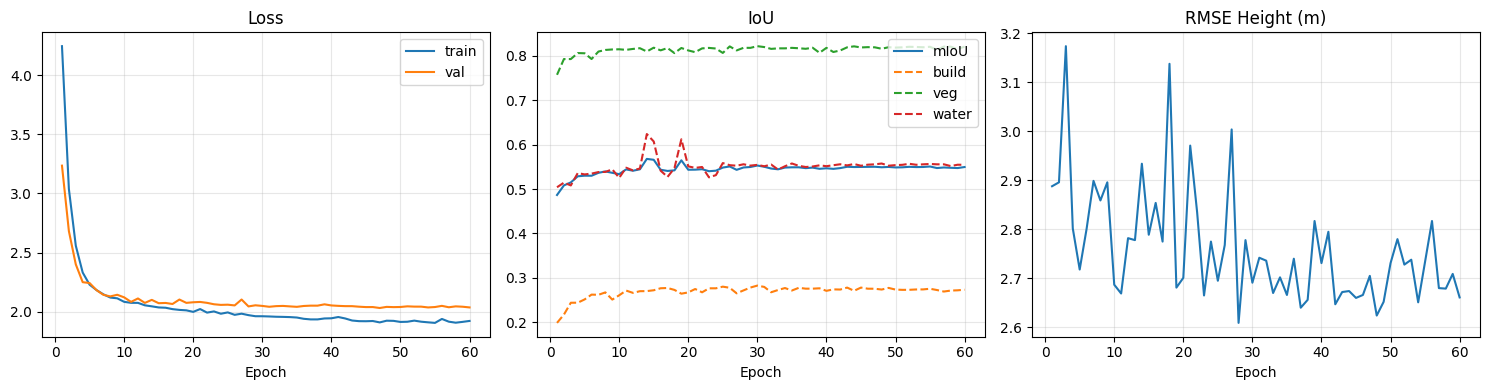

 epoch    trn    val   miou  iou_b  iou_v  iou_w  rmse_h
    51 1.9165 2.0467 0.5489 0.2732 0.8188 0.5545   2.780
    52 1.9260 2.0443 0.5500 0.2733 0.8200 0.5568   2.728
    53 1.9169 2.0441 0.5494 0.2741 0.8196 0.5546   2.738
    54 1.9116 2.0374 0.5496 0.2742 0.8189 0.5556   2.651
    55 1.9069 2.0408 0.5507 0.2757 0.8200 0.5564   2.734
    56 1.9402 2.0507 0.5472 0.2728 0.8131 0.5556   2.817
    57 1.9171 2.0389 0.5485 0.2694 0.8204 0.5556   2.680
    58 1.9085 2.0464 0.5478 0.2716 0.8202 0.5517   2.679
    59 1.9155 2.0434 0.5472 0.2722 0.8147 0.5547   2.709
    60 1.9233 2.0375 0.5495 0.2735 0.8204 0.5545   2.661


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

history = load_history()
df  = pd.DataFrame(history)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(df.epoch, df.trn, label='train')
axes[0].plot(df.epoch, df.val, label='val')
axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(df.epoch, df.miou,  label='mIoU')
axes[1].plot(df.epoch, df.iou_b, label='build', linestyle='--')
axes[1].plot(df.epoch, df.iou_v, label='veg',   linestyle='--')
axes[1].plot(df.epoch, df.iou_w, label='water', linestyle='--')
axes[1].set_title('IoU'); axes[1].legend()
axes[2].plot(df.epoch, df.rmse_h)
axes[2].set_title('RMSE Height (m)')
for ax in axes: ax.set_xlabel('Epoch'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(df.tail(10).to_string(index=False))

## 9 — Copy test files to local SSD

In [ ]:
LOCAL_TEST_AE = Path('/content/test_ae')
LOCAL_TEST_TM = Path('/content/test_tm')
LOCAL_TEST_AE.mkdir(exist_ok=True)
LOCAL_TEST_TM.mkdir(exist_ok=True)

for src_dir, dst_dir, label in [
    (AE_TEST, LOCAL_TEST_AE, 'AE test'),
    (TM_TEST, LOCAL_TEST_TM, 'TM test'),
]:
    files   = sorted(src_dir.glob('*.tif'))
    missing = [f for f in files if not (dst_dir/f.name).exists()]
    if missing:
        print(f'Copying {len(missing)} {label} files…')
        for p in missing: safe_copy(p, dst_dir/p.name)
    else:
        print(f'{label}: already on SSD ({len(files)} files)')

print(f'AE test:{len(list(LOCAL_TEST_AE.glob("*.tif")))}  '
      f'TM test:{len(list(LOCAL_TEST_TM.glob("*.tif")))}')

Copying 946 AE test files…
Mounted at /content/drive
Copying 946 TM test files…
AE test:946  TM test:946


## 10 — Inference & submission

In [ ]:
# Load best checkpoint
ckpt = torch.load(CKPT_BEST, map_location=DEVICE, weights_only=False)
try:
    model.load_state_dict(ckpt['model'])
except RuntimeError:
    model._orig_mod.load_state_dict(ckpt['model'])
model.eval()
print(f'Loaded best checkpoint epoch {ckpt["epoch"]}  val_loss={ckpt["val_loss"]:.4f}')

# Index test files
ae_test_map = {patch_id(p.stem): p
               for p in LOCAL_TEST_AE.glob('*.tif') if patch_id(p.stem)}
tm_test_map = {patch_id(p.stem): p
               for p in LOCAL_TEST_TM.glob('*.tif') if patch_id(p.stem)}
test_ids    = sorted(ae_test_map.keys() & tm_test_map.keys())
print(f'Test patches: {len(test_ids)}')
assert len(test_ids) == 946, f'Expected 946, got {len(test_ids)}'

SUB_PRED = Path('/content/predictions')
SUB_PRED.mkdir(exist_ok=True)

for pid in test_ids:
    ae = load_tif(ae_test_map[pid], target_hw=256).astype(np.float32)
    ae = np.nan_to_num((ae - AE_MEAN) / (AE_STD + 1e-6), nan=0.0)
    tm = load_tif(tm_test_map[pid]).astype(np.float32)
    tm = np.nan_to_num((tm - TM_MEAN) / (TM_STD + 1e-6), nan=0.0)

    ae_t = torch.from_numpy(ae).unsqueeze(0).to(DEVICE)
    tm_t = torch.from_numpy(tm).unsqueeze(0).to(DEVICE)

    with torch.no_grad(), torch.amp.autocast('cuda'):
        seg_p, h_p = model(ae_t, tm_t)

    seg_np = torch.sigmoid(seg_p).squeeze(0).float().cpu().numpy()
    h_np   = torch.expm1(h_p).clamp(0).squeeze(0).float().cpu().numpy()
    pred   = np.concatenate([seg_np, h_np], axis=0).astype(np.float32)

    # Naming: s2_3335_MM_2022_embeddings → 3335_MM_2022.npy
    stem  = tm_test_map[pid].stem
    clean = re.sub(r'^s2_', '', re.sub(r'_embeddings$', '', stem))
    np.save(SUB_PRED / f'{clean}.npy', pred)

n_saved = len(list(SUB_PRED.glob('*.npy')))
print(f'Saved {n_saved} / 946 predictions')

SUB_ZIP = DRIVE_ROOT / 'submission_attn.zip'
with zipfile.ZipFile(SUB_ZIP, 'w', zipfile.ZIP_DEFLATED) as zf:
    for npy in sorted(SUB_PRED.glob('*.npy')):
        zf.write(npy, f'predictions/{npy.name}')
print(f'Zip: {SUB_ZIP}  ({SUB_ZIP.stat().st_size/1e6:.1f} MB)')

Loaded best checkpoint epoch 47  val_loss=2.0326
Test patches: 946
Saved 946 / 946 predictions
Zip: /content/drive/MyDrive/ESA_Challenge/submission_attn.zip  (460.0 MB)


## 11 — Sanity check

In [ ]:
with zipfile.ZipFile(SUB_ZIP) as zf:
    names = zf.namelist()
    print(f'Files in zip: {len(names)}')
    arr = np.load(zf.open(names[0]))
    print(f'Shape : {arr.shape}')
    print(f'Build : {arr[0].min():.3f} – {arr[0].max():.3f}')
    print(f'Veg   : {arr[1].min():.3f} – {arr[1].max():.3f}')
    print(f'Water : {arr[2].min():.3f} – {arr[2].max():.3f}')
    print(f'Height: {arr[3].min():.1f}m – {arr[3].max():.1f}m')

Files in zip: 946
Shape : (4, 256, 256)
Build : 0.000 – 0.994
Veg   : 0.000 – 1.000
Water : 0.000 – 0.786
Height: 0.0m – 19.7m
